In [15]:
suppressPackageStartupMessages(library(tidyverse))
library(here)
library(dplyr)
library(ggplot2)

options(box.path = here())
box::use(r / load)

r_out <- here("reports", "figures")

box::reload(load)


IMG_WIDTH <- 18
IMG_HEIGHT <- 9


In [2]:
df_full <- readRDS(here("data", "interim", "regression_results.rds"))


In [3]:
cmap <- load$colormap()

party_name_map <- c(
  afd = "AfD",
  cdu_csu = "CDU/CSU",
  fdp = "FDP",
  greens = "Greens",
  left = "Left",
  spd = "SPD"
)

df <- df_full |>
  filter(quantile <= 0.99) |>
  mutate(party = recode(party, !!!party_name_map))


In [ ]:
plot_coefs <- function(df, model_type, term, x, y) {
  df_elite <- df |>
    dplyr::filter(model_type == {{ model_type }}, term == {{ term }})

  df_r2 <- df |>
    filter(model_type == {{ model_type }}, term == "R2") |>
    transmute(party, quantile, R2 = est)

  plot_df <- df_elite |>
    left_join(df_r2, by = c("party", "quantile"))

  est_max <- max(plot_df$upper_ci, 0, na.rm = TRUE)
  r2_max <- max(plot_df$R2, na.rm = TRUE)
  a <- est_max / r2_max # zero-anchored linear mapping

  to_primary <- function(r2) a * r2 # R2 -> primary y (0 -> 0)
  to_secondary <- function(y) y / a # primary y -> R2    (0 -> 0)

  plot <- ggplot(plot_df, aes(x = quantile, y = est, color = party, fill = party)) +
    geom_line() +
    geom_ribbon(aes(ymin = lower_ci, ymax = upper_ci), linetype = 2, alpha = 0.2) +
    geom_hline(yintercept = 0, color = "black", linetype = "dashed") +
    geom_line(aes(y = to_primary(R2)), color = "black", linewidth = 0.6) +
    facet_wrap(
      ~party,
      scales = "fixed",
      ncol = 3
    ) +
    labs(
      x = x,
      y = y
    ) +
    scale_color_manual(values = cmap) +
    scale_fill_manual(values = cmap) +
    scale_y_continuous(
      trans = scales::pseudo_log_trans(sigma = 3.7),
      breaks = scales::pretty_breaks(),
      sec.axis = sec_axis(~ to_secondary(.), name = expression(R^2))
    ) +
    theme_minimal(base_size = 9) +
    theme(legend.position = "none")

  return(plot)
}


# Views Elite


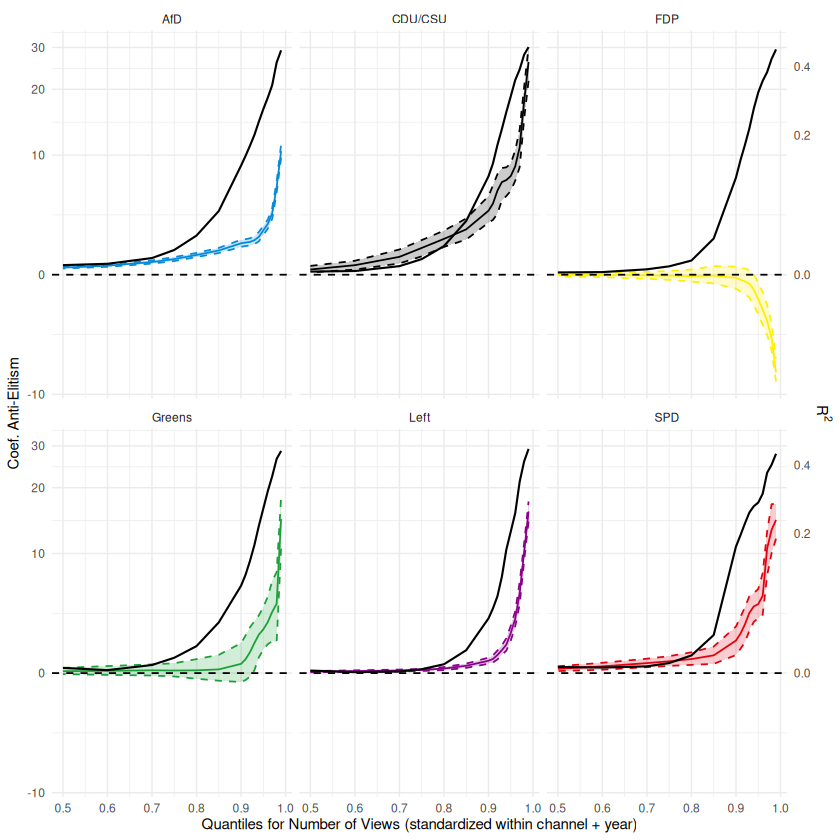

In [ ]:
plot <- plot_coefs(
  df,
  model_type = "views_elite",
  term = "elite",
  x = "Quantiles for Number of Views\n(standardized within channel + year)",
  y = "Coef. Anti-Elitism"
)

plot


In [8]:
path <- here("reports", "figures", "reg_views_elite.jpg")
if (file.exists(path)) file.remove(path)

ggsave(
  path,
  plot,
  units = "cm",
  dpi = 900,
  width = IMG_WIDTH,
  height = IMG_HEIGHT
)


# Views Pplcentr


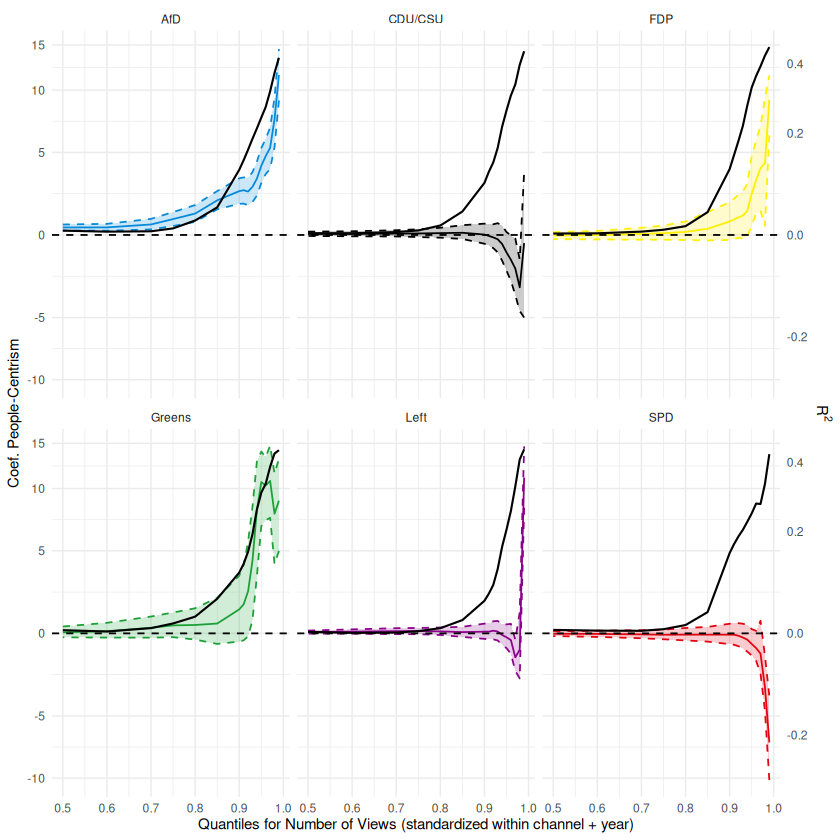

In [ ]:
plot <- plot_coefs(
  df,
  model_type = "views_pplcentr",
  term = "pplcentr",
  x = "Quantiles for Number of Views\n(standardized within channel + year)",
  y = "Coef. People-Centrism"
)

plot


In [10]:
path <- here("reports", "figures", "reg_views_pplcentr.jpg")
if (file.exists(path)) file.remove(path)

ggsave(
  path,
  plot,
  units = "cm",
  dpi = 900,
  width = IMG_WIDTH,
  height = IMG_HEIGHT
)


# Likes Elite


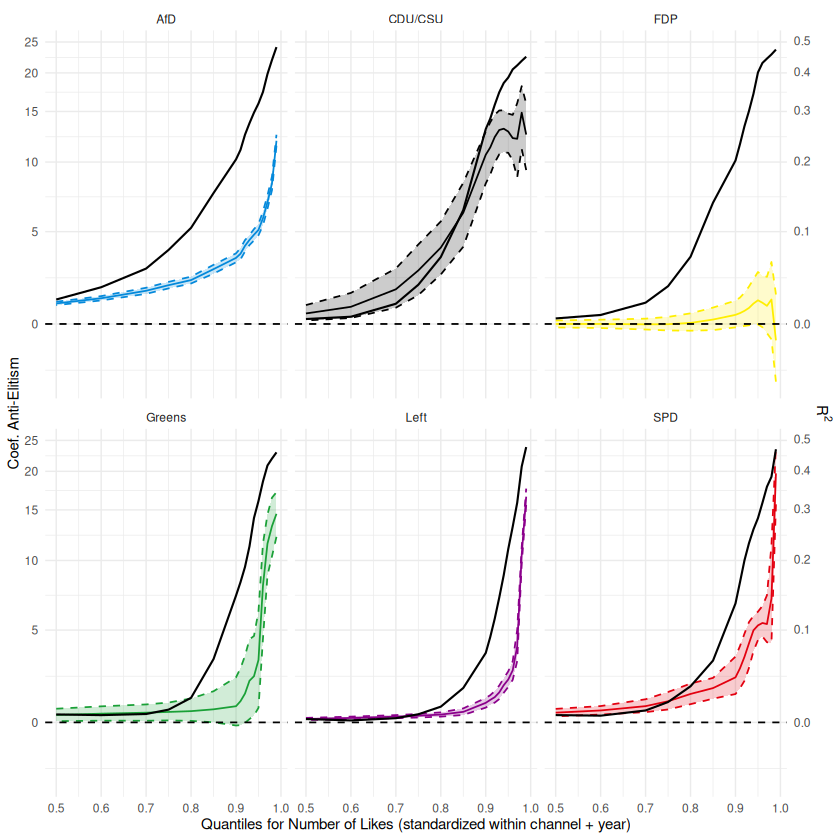

In [ ]:
plot <- plot_coefs(
  df,
  model_type = "likes_elite",
  term = "elite",
  x = "Quantiles for Number of Likes\n(standardized within channel + year)",
  y = "Coef. Anti-Elitism"
)

plot


In [12]:
path <- here("reports", "figures", "reg_likes_elite.jpg")
if (file.exists(path)) file.remove(path)

ggsave(
  path,
  plot,
  units = "cm",
  dpi = 900,
  width = IMG_WIDTH,
  height = IMG_HEIGHT
)


# Likes Pplcentr


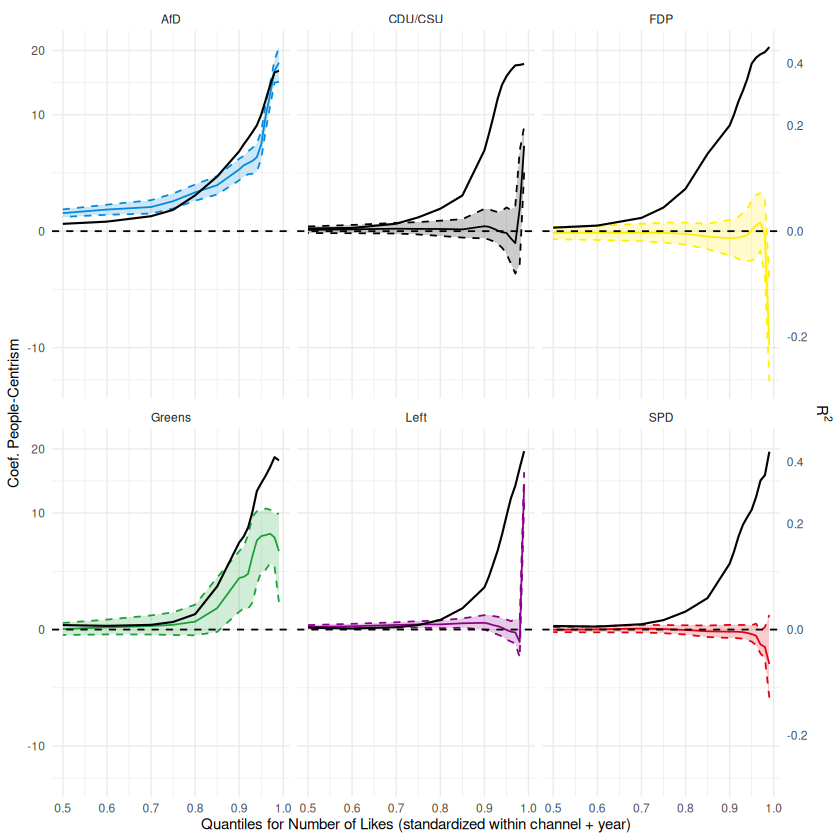

In [ ]:
plot <- plot_coefs(
  df,
  model_type = "likes_pplcentr",
  term = "pplcentr",
  x = "Quantiles for Number of Likes\n(standardized within channel + year)",
  y = "Coef. People-Centrism"
)

plot


In [14]:
path <- here("reports", "figures", "reg_likes_pplcentr.jpg")
if (file.exists(path)) file.remove(path)

ggsave(
  path,
  plot,
  units = "cm",
  dpi = 900,
  width = IMG_WIDTH,
  height = IMG_HEIGHT
)
